# Проект 12 спринта: предсказание вероятности клика AdTech платформы Advandex

**Выполнил:** Артем Буров  
**Группа:** DS12  
**Дата:** 13 июня 2026  
**Ссылка на GitHub:** https://github.com/TemaQDX/sprint_12_project_advandex
___

## Описание задачи

Построить модель бинарной классификации для AdTech‑платформы Advandex, которая предсказывает вероятность клика (CTR) на рекламное объявление, провести калибровку этой модели, чтобы обеспечить соответствие между предсказанными вероятностями и фактической частотой кликов.

Некорректные прогнозы несут прямые финансовые риски для платформы: если модель систематически завышает CTR (например, предсказывает 20 % при реальных 5 %), это приведёт к перерасходу бюджета рекламодателей, потере их доверия и неэффективным победам в аукционах. Напротив, заниженные оценки (5 % вместо реальных 20 %) заставят платформу проигрывать аукционы за перспективные показы — и терять потенциальный доход.

Конечная цель — создать точную и достоверную модель, в которой предсказанный показатель CTR максимально близко отражает реальную вероятность клика: если модель выдаёт 20 %, то в среднем клик должен происходить в 20 случаях из 100. Такая калибровка критически важна для бизнес‑модели Advandex, поскольку достоверность предсказаний напрямую влияет на эффективность аукционов и финансовые результаты платформы.
___

## Выбор метрик

Для оценки модели в этом проекте будут использованы три ключевые метрики:

- **PR-AUC** — основная метрика. Она наиболее адекватно оценивает качество модели на несбалансированных данных. Клики — это более редкое событие, чем пропуск рекламы, но при этом оно критически важно для бизнеса. Поэтому метрика PR-AUC идеально подойдёт. Она игнорирует дисбаланс классов и позволяет оценить, насколько хорошо модель находит именно целевые действия — клики.
- **Log Loss** позволит оценить точность предсказанных вероятностей. Это важно, чтобы оптимизировать ставки на аукционах, где от достоверности вероятностей напрямую зависит эффективность расходов рекламодателей.
- **Оценка Бриера** измеряет и точность, и калибровку модели, то есть общее соответствие прогнозов реальным результатам. Для платформы это имеет прямое финансовое значение, так как ошибки в прогнозах приводят либо к переплатам, либо к упущенной выгоде.

При необходимости используйте дополнительные метрики. Они могут помочь в спорных ситуациях:

- Для детального анализа калибровки пригодятся метрики **ECE** и **MCE**. Они оценивают, насколько хорошо откалиброваны предсказанные вероятности по разным диапазонам.
- Вспомогательные метрики точности:
  - **Precision** — точность предсказания кликов.
  - **Recall** — полнота охвата реальных кликов.
  - **F1-score** — балансирует точность и полноту.
___


## Описание данных

#### Идентификаторы и временные метки:

- `id` — уникальный идентификатор записи о показе баннера;
- `hour` — час, в который был показан баннер, в формате `YYMMDDHH`.

#### Характеристики рекламной площадки (Site):

- `site_id` — идентификатор веб-сайта, на котором был показан баннер;
- `site_domain` — домен веб-сайта;
- `site_category` — тематическая категория веб-сайта.

#### Характеристики рекламируемого приложения (App):

- `app_id` — идентификатор рекламируемого мобильного приложения;
- `app_domain` — домен рекламируемого приложения;
- `app_category` — категория рекламируемого приложения.

#### Характеристики устройства и соединения пользователя:

- `device_id` — идентификатор браузера или устройства;
- `device_ip` — IP-адрес устройства;
- `device_model` — модель устройства;
- `device_type` — тип устройства пользователя: например, смартфон, планшет, ПК;
- `device_conn_type` — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

#### Характеристики рекламного баннера и аукциона:

- `C1` — анонимизированный признак, характеризующий контекст показа;
- `banner_pos` — позиция баннера на веб-странице;
- `C14` — `C21` — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

#### Машинно-сгенерированные признаки (ML Features):

- `ml_feature_1`, `ml_feature_3` — `ml_feature_6`, `ml_feature_8` — `ml_feature_10` — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;
- `ml_feature_2`, `ml_feature_7` — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

#### Целевая переменная:

- `click` — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.
___


# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.
___

In [1]:
# Загружаем базовые библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Проверка наличия jinja2 для отражения тепловой карты корреляций
try:
    import jinja2
except:
    %pip install jinja2

# Загружаем библиотеку для расчёта коэффициента корреляции Phik
try:
    from phik import phik_matrix
except:
    %pip install phik
    from phik import phik_matrix

# Предобрабока данных
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from category_encoders import  LeaveOneOutEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold

# Загружаем модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Метрики
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, average_precision_score, classification_report

# Системные библиотеки, настройки отображения датафреймов и предупредительных сообщений
import joblib
import os
import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

path = os.getcwd()
RANDOM_SEED = 555

In [2]:
# Подготавливаем функции визуализации данных

def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Количество',
    title='Столбчатая диаграмма',
    top_n=5
):
    """
    Строит столбчатую диаграмму с метками значений и процентов.

    Параметры:
    -----------
    data : array-like или pd.Series
        Вектор данных для построения диаграммы.
    figsize : tuple, optional
        Размер фигуры (ширина, высота) в дюймах. По умолчанию (12, 6).
    xlabel : str, optional
        Подпись оси X (по умолчанию 'Категория').
    ylabel : str, optional
        Подпись оси Y (по умолчанию 'Количество').
    title : str, optional
        Заголовок графика (по умолчанию 'Столбчатая диаграмма').
    top_n : int, optional
        Количество категорий для отображения (самые частые). По умолчанию 5.
    """
    # Преобразуем данные в Series, если это ещё не сделано
    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    # Подсчёт значений и отбор топ‑N категорий
    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    # Создаём контейнер графика matplotlib и задаём его размер
    plt.figure(figsize=figsize)

    # Строим столбчатую диаграмму
    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    # Добавляем сетку графика
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Добавление меток на столбики (абсолютные значения)
    for i, v in enumerate(value_counts):
        # Смещение по Y пропорционально общему количеству для лучшей читаемости
        y_offset = 0.001 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    # Добавление меток процентов
    for i, v in enumerate(value_counts_normalized):
        # Позиция по Y — половина высоты столбца (чтобы надпись была по центру)
        y_pos = (v * total) / 2
        ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )

    # Улучшаем отображение, чтобы избежать обрезания элементов
    plt.tight_layout()

    # Выводим график
    plt.show()


In [3]:
# Загружаем датасет

df_init = pd.read_csv('https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv')

In [4]:
# Знакомимся с данными
df_init.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [5]:
df_init.shape

(50000, 34)

In [6]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

In [7]:
# Создадим функцию оптимизации типов данных датафрейма
def optimize_dataframe(df):
    dataset_cols_float = df.select_dtypes(include=['float64', 'float32']).columns.tolist()
    dataset_cols_int = df.select_dtypes(include=['int64', 'int32']).columns.tolist()

    for col in dataset_cols_float:
        df[col] = pd.to_numeric(df[col], downcast='float')

    for col in dataset_cols_int:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    return df

In [8]:
# Оптимизируем типы данных датафрейма и сохраним в новый рабочий датафрейм df_work. Первоначальный df_init оставим для отслеживания изменений. 

df_work = optimize_dataframe(df_init)

## Комментарий по итогам подготовки среды и загрузки данных

- Подготовлено виртуальное окружение, состав библиотек проекта зафиксирован в файле `requirements.txt`.
- Импортированы все необходимые библиотеки и настроены системные параметры, а также параметры отображения графиков и датафреймов. Зафиксирована константа `RANDOM_SEED = 555`.
- Данные загружены успешно. Датасет содержит 34 атрибута и 50 000 записей.
- На основе начального датафрейма создан новый с оптимизированной структурой типов данных. Начальный датафрем оставлен для сравнения и отслеживания изменений по ходу проекта.
___

## 2. Исследовательский анализ данных (EDA)

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.
___

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

In [9]:
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int8   
 2   hour              50000 non-null  int32  
 3   C1                50000 non-null  int16  
 4   banner_pos        50000 non-null  int8   
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int8   
 15  device_conn_type  50000 non-null  int8   
 16  C14               50000 non-null  int16  
 17  C15 

In [10]:
# Проверим на наличие явных дубликатов
df_work.duplicated().sum()

np.int64(0)

In [11]:
# Проверим на начиличие неявных дубликатов, исключив id показа
df_work.drop(columns=['click']).duplicated().sum()

np.int64(0)

#### Объём данных

- **Количество объектов (строк):** 50 000 (RangeIndex от 0 до 49 999).
- **Количество признаков (столбцов):** 34.
- **Пропуски:** Не обнаружены (во всех 34 колонках указано `50000 non-null`).
- **Дубликаты:** Не обнаружены.

#### Типы данных

В датасете представлены следующие основные типы данных:

- **Числовые:**
  - `float32` (7 колонок): `ml_feature_1`, `ml_feature_3`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10`.
  - `float64` (1 колонка): `id`.
  - `int16` (7 колонок): `C1`, `C14`–`C17`, `C19`.
  - `int32` (2 колонки): `hour`, `C20`.
  - `int8` (6 колонок): `click`, `banner_pos`, `device_type`, `device_conn_type`, `C18`.

- **Категориальные / Строковые:**
  - `str` (11 колонок): `site_id`, `site_domain`, `site_category`, `app_id`, `app_domain`, `app_category`, `device_id`, `device_ip`, `device_model`, `ml_feature_2`, `ml_feature_7`.

#### Общее описание и контекст

Датасет описывает **показы рекламных баннеров** и содержит информацию, позволяющую связать контекст показа с поведением пользователя (кликом или его отсутствием).

**Что известно о рекламе:**
- **Площадка:** `site_id`, `site_domain`, `site_category` — где именно был показан баннер (сайт, его домен и тематика).
- **Продукт/Приложение:** `app_id`, `app_domain`, `app_category` — что рекламировалось (идентификатор, домен и категория приложения).
- **Позиция и контекст:** `banner_pos` (позиция на странице), `C1` (контекст показа), анонимизированные признаки `C14`–`C21` (дополнительные параметры аукциона/баннера).

**Что известно о пользователе:**
- **Устройство:** `device_model`, `device_type` (смартфон, ПК и т. д.), `device_conn_type` (тип соединения: Wi-Fi, 3G и др.).
- **Идентификаторы:** `device_id`, `device_ip` — для отслеживания конкретного устройства/пользователя.

**Целевая переменная:**
- `click` (тип `int8`) — бинарный признак, указывающий, был ли совершён клик (1 — клик был, 0 — не было). Это наша **целевая метка** для задачи бинарной классификации.

**Дополнительные признаки:**
- **Машинно-сгенерированные (`ml_feature_*`):** Представляют собой результат предварительной обработки. Включают как числовые (вероятно, агрегированные статистики), так и категориальные признаки.

**Краткий вывод:**  
Датасет сбалансирован по полноте (нет пропусков), не содержит дубликатов, содержит информацию как о рекламе, так и о пользователе, и готов к исследовательскому анализу и дальнейшей предобработке.
___


#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

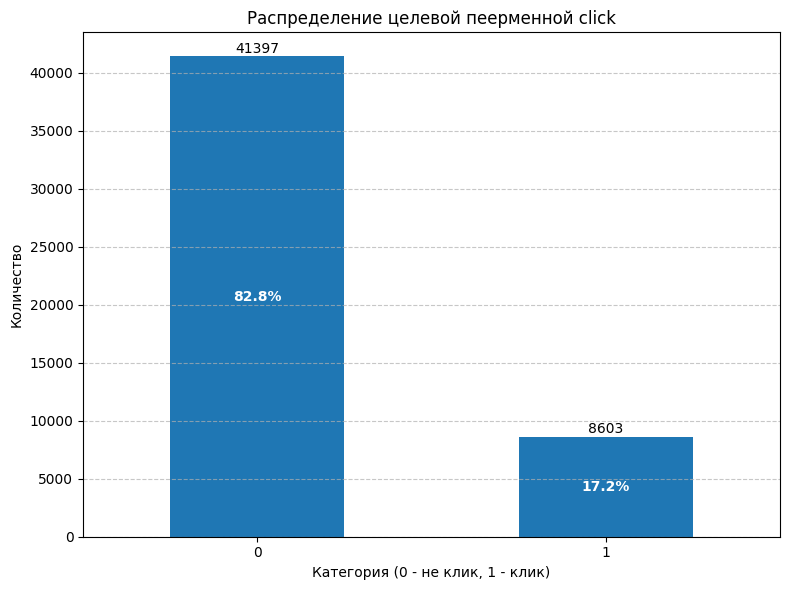

In [12]:
plot_bar_chart(data=df_work['click'], figsize=(8, 6), xlabel='Категория (0 - не клик, 1 - клик)', ylabel='Количество', title='Распределение целевой пеерменной click')

#### Целевая переменная `click`

1. **Распределение классов**  
   Целевая переменная `click` имеет два значения:
   - `0` (не клик) — **41 397** записей (82.8%);
   - `1` (клик) — **8 603** записи (17.2%).

2. **Наличие дисбаланса**  
   В датасете **явно выражен дисбаланс классов**.  
   Класс «не клик» (`0`) значительно преобладает над классом «клик» (`1`) в соотношении примерно **5 к 1**.  

3. **Выбор метрик**  
   Дисбаланс классов обосновывает использование в качестве основных метрик модели:
- **PR-AUC** (Precision-Recall AUC) - особенно информативен при сильном дисбалансе.
- **Precision (точность)** — доля верно предсказанных кликов среди всех предсказаний «клик».
- **Recall (полнота)** — доля реальных кликов, которые модель смогла найти.
- **F1-score** — гармоническое среднее между Precision и Recall (хорошо подходит для несбалансированных данных).
___


#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

In [13]:
df_work.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146790,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319133,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [14]:
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int8   
 2   hour              50000 non-null  int32  
 3   C1                50000 non-null  int16  
 4   banner_pos        50000 non-null  int8   
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int8   
 15  device_conn_type  50000 non-null  int8   
 16  C14               50000 non-null  int16  
 17  C15 

In [15]:
# Напишем простую функцию удаления ненужных колонок
def drop_unneccesary_columns(df, cols_2_drop):
    return df.drop(columns=cols_2_drop)

In [24]:
# Сдлаем первое разделение на категориальные и числовые характеристики
float_cols = df_work.select_dtypes(include=['float64', 'float32']).columns.tolist() 
int_cols = df_work.select_dtypes(include=['int8', 'int16', 'int32', 'int64']).columns.tolist() + ['hour', 'C20'] # по какой то принине не видит тип int32. Добавляем в ручную. 
cat_cols = df_work.select_dtypes(include=['str']).columns.tolist()

len(float_cols + int_cols + cat_cols) # Проверим, что ничего не потеряли. Всего 34 признака, включая целевую переменную.

34

In [25]:
# Посмотрим на кагориальные признаки с типом str
df_work[cat_cols].describe()

,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,ml_feature_2,ml_feature_7
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,1160,1013,18,976,67,22,8580,41455,2521,5,3
top,85f751fd,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,a99f214a,6b9769f2,8a4875bd,E,Y
freq,18011,18645,20457,31989,33763,32388,41213,265,3007,10112,17081


In [31]:
# Посомтрим на целочисленные признаки как на категориальные

# Час показа баннера показан в формате даты. Приведем именно часу, как к категории времени суток.
df_work['hour'] = df_work['hour'] % 100

df_work[int_cols].astype('str').describe()

,click,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C21,ml_feature_4,hour,C20
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,2,7,7,4,4,1497,8,9,387,4,64,59,2,24,149
top,0,1005,0,1,0,4687,320,50,1722,0,35,23,0,13,-1
freq,41397,45835,35883,46031,43021,1200,46787,47287,5637,21074,14964,10919,25098,3013,23443


In [ ]:
# Посмотрим на признаки с плавающей точкой
df_work[float_cols].describe()

,id,ml_feature_1,ml_feature_3,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.215402e+18,-0.002445,-0.036381,0.034729,0.022948,0.025465,0.035361,0.020226
std,5.328516e+18,1.000280,5.792335,1.002116,0.656690,0.578026,0.505034,0.303309
min,3.191077e+13,-4.631262,-9.999742,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,4.580649e+18,-0.677784,-5.059555,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,9.243015e+18,-0.003776,-0.056155,0.028112,0.037786,0.027348,0.035985,0.018930
75%,1.380920e+19,0.673534,4.985939,0.707594,0.637131,0.521117,0.374152,0.224080
max,1.844652e+19,3.793828,9.999975,4.230623,1.000000,1.119858,2.120786,1.202300


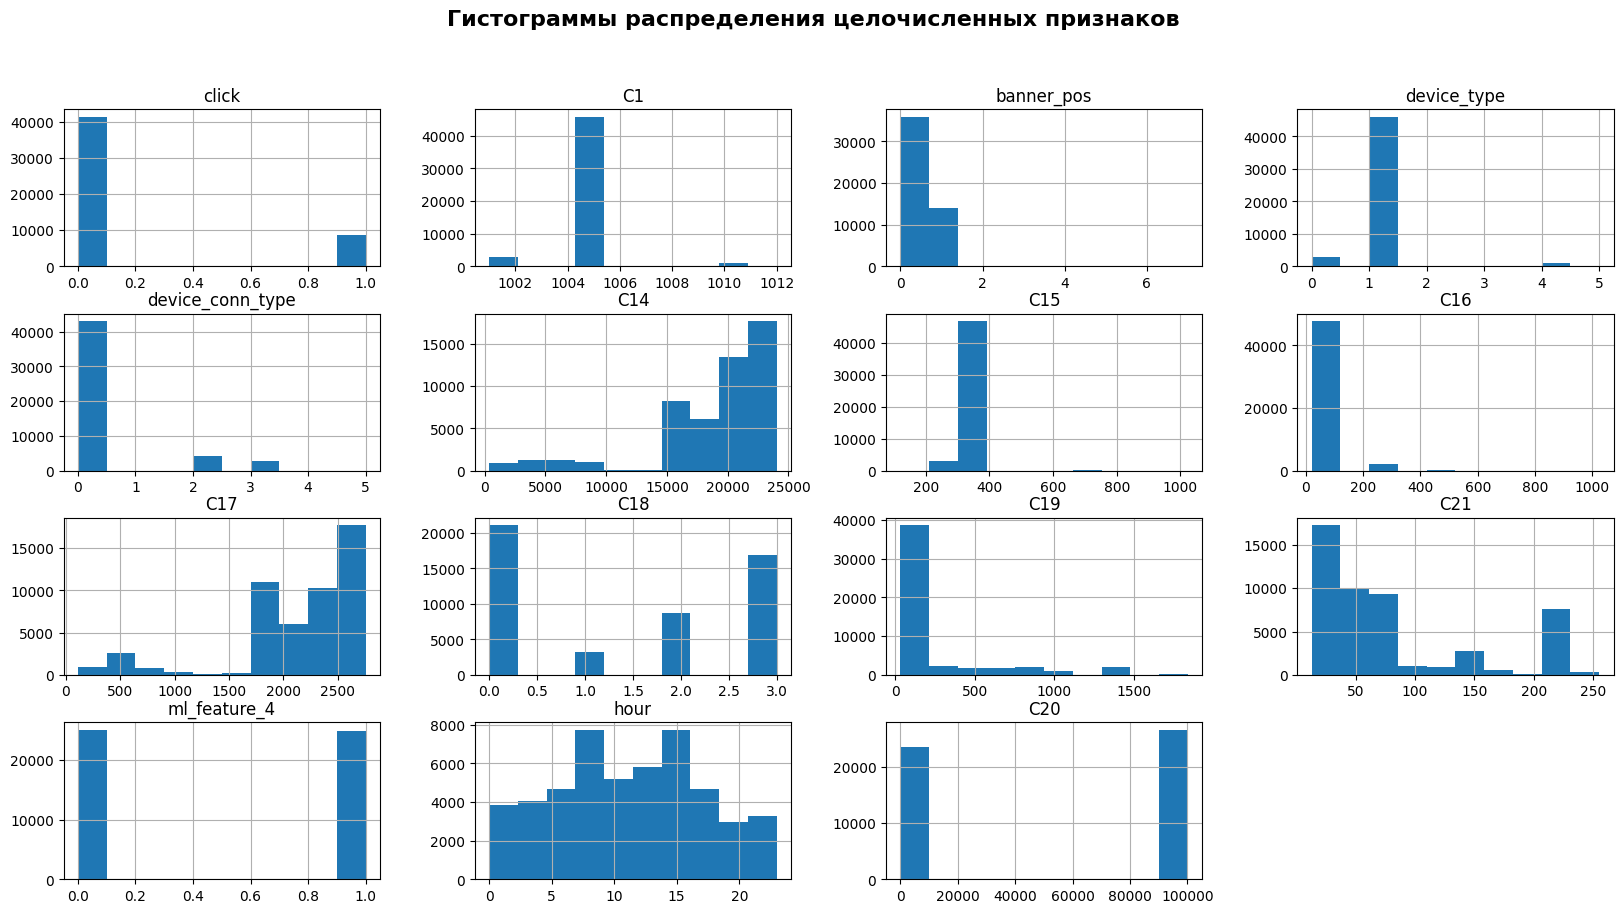

In [ ]:
# Посмотрим на целочисленные признаки них на графиках. 
df_work[int_cols].hist(figsize=(20, 10))
plt.suptitle('Гистограммы распределения целочисленных признаков', fontsize=16, fontweight='bold')
plt.show()

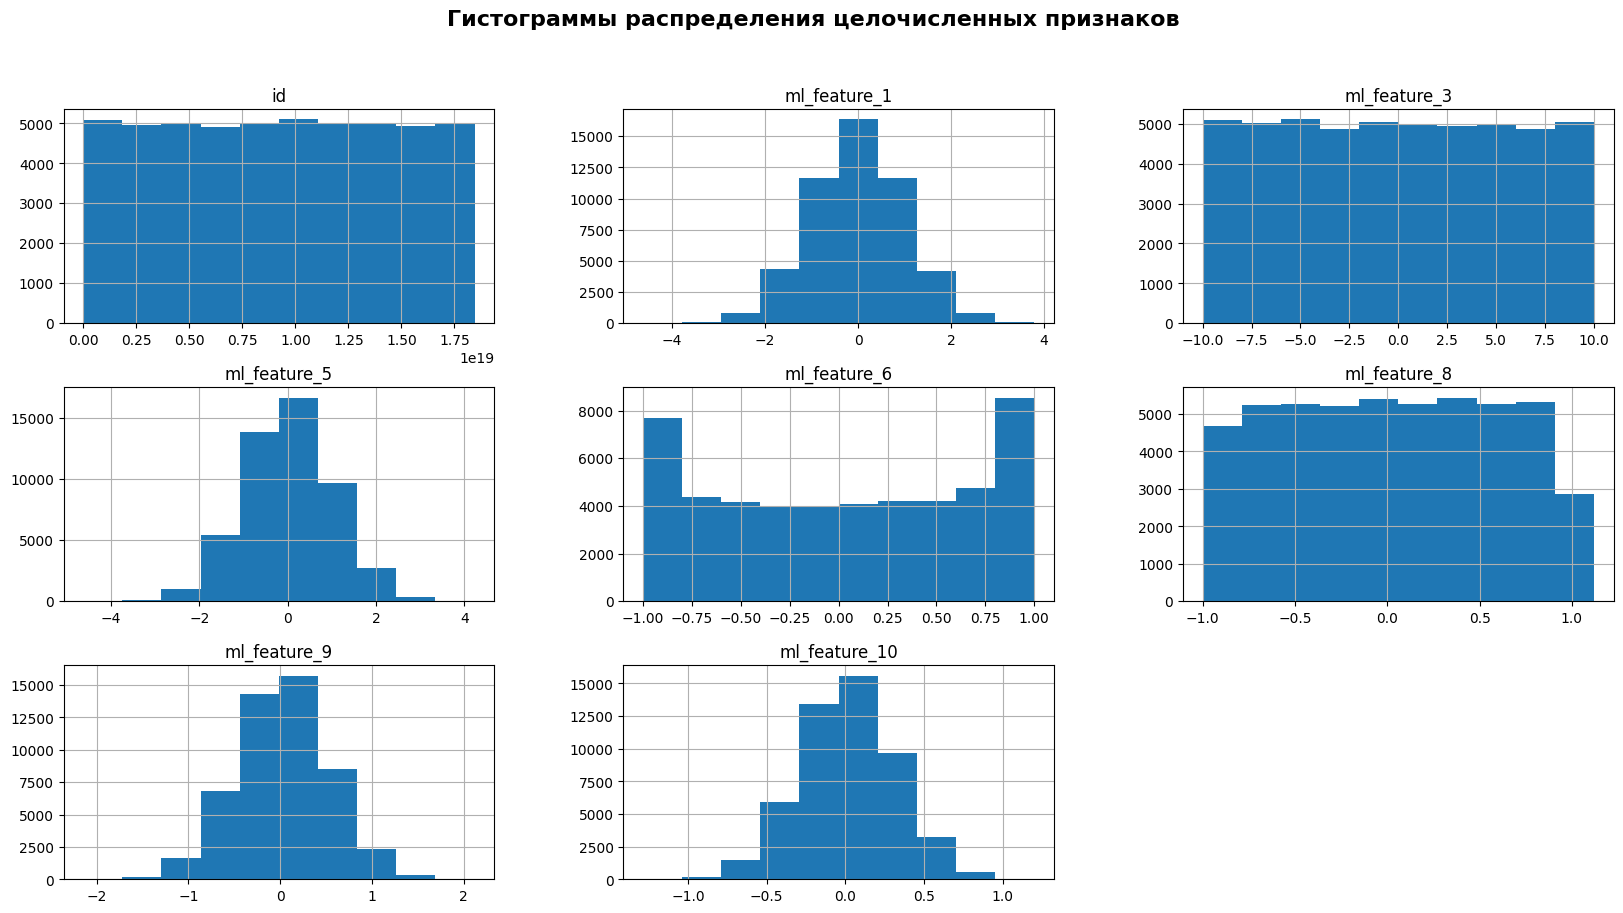

In [36]:
# Посмотрим на признаки с плавающей точкой на графиках. 
df_work[float_cols].hist(figsize=(20, 10))
plt.suptitle('Гистограммы распределения целочисленных признаков', fontsize=16, fontweight='bold')
plt.show()

In [ ]:
# Классифицируем признаки: целевая переменная и колонки, которые можно удалить
target = ['click'] # Целевая переменная
columns_to_drop = ['id', 'device_type', 'device_id', 'device_ip', 'device_model', 'device_conn_type'] # Есть сомнение, что идентификатор показа и характеристики устройства и соединения пользователя могут влиять на принятие им решения о клике
cat_features = [item for item in int_cols + cat_cols if item not in target + columns_to_drop] # К категориальным принакам относим все текстовые и целовисленные переменные
num_features = [item for item in float_cols if item not in target + columns_to_drop] # К числовым признакам относим числа с плавающей точкой

len(target + columns_to_drop + cat_features + num_features)

34

In [38]:
# Удалим ненужные колонки
df_work = optimize_dataframe(drop_unneccesary_columns(df_work, columns_to_drop))
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   click          50000 non-null  int8   
 1   hour           50000 non-null  int32  
 2   C1             50000 non-null  int16  
 3   banner_pos     50000 non-null  int8   
 4   site_id        50000 non-null  str    
 5   site_domain    50000 non-null  str    
 6   site_category  50000 non-null  str    
 7   app_id         50000 non-null  str    
 8   app_domain     50000 non-null  str    
 9   app_category   50000 non-null  str    
 10  C14            50000 non-null  int16  
 11  C15            50000 non-null  int16  
 12  C16            50000 non-null  int16  
 13  C17            50000 non-null  int16  
 14  C18            50000 non-null  int8   
 15  C19            50000 non-null  int16  
 16  C20            50000 non-null  int32  
 17  C21            50000 non-null  int16  
 18  ml_feature_1   50

#### Выводы по анализу признаков

В датасете 34 атрибута. Из них 1 целевая переменная `click`.

Принято решение **удалить как несущественные** идентификаторы показа баннера, а также признаки описывающие устройство пользователя:
- `id` - уникальный идентификатор записи о показе баннера;
- `device_id` - идентификатор браузера или устройства;
- `device_ip` - IP-адрес устройства;
- `device_model` - модель устройства;
- `device_type` - тип устройства пользователя;
- `device_conn_type` - тип сетевого соединения устройства
Всё это фоновые признаки, которые не оказывают влияния на принятие пользователем решения о клике.

К **категориальным признакам** относятся все признаки типа 'str' и целочисленные призаки датасета. Целовисленные признаки в описании к задаче даны как *аномизированные признаки, характеризующие контекст показа*, они содержат довольно мало уникальных значений (не более 70 при 50 тыс. записей в датасете). То есть можно сделать вывод о том, что они скорее несут цифровое обозначение некой категории, возможно даже порядковый признак, но не числовую характеристику. Исключение по числу уникальных значентий составляют `C14` - 1497, `C17` - 387 и `C20` - 149. Но характер их распределения (смещенный влево), нетипичный для числовых признаков, и то, что в описании к задаче они даны в одной группе без разделения, также говорит в пользу того, что это скорее не числовые характеристики.
Признак `hour`, имевший формат YYMMDDHH приведен к часу HH, как характеристики времени суток, из него исключены данные о дате YYMMDD.

В **числовым признакам** были отнесены все колонки с типом 'float'. Имеют распределение похожее на нормальное (`ml_featue_1`, `ml_feature_5`, `ml_feature_9`, `ml_feature_10`), равномерное распределение (`ml_feature_3`, `ml_feature_8`) и распределение с двумя вершинами по краям у `ml_feature_6`.

Итого в датасете остается **27 признаков и одна целевая переменная**.

___

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

In [21]:
df_work.isna().sum().sum()

np.int64(0)

In [22]:
df_work.isnull().sum().sum()

np.int64(0)

#### Выводы по итогам анализа пропущенных значений

В датасете отсутствуют. В дальнейшем при создании пайплайна для промышленной обработки пропусков `SimpleImputer` будем придерживаться для категориальных признаков рекомендованной в инструкции методики заполнения через моду или новой категорией 'unknown'. Для числовых признаков выбор будет между медианой и средним значением. Рекомендации к выбору заполнения пропусков в этих двух классах переменных будут приняты после анализа распределений и выбросов.
___

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

In [23]:
df_work[categorical_features].head()

,site_id,site_domain,site_category,app_id,app_domain,app_category,ml_feature_2,ml_feature_7,C1,C18,C20,ml_feature_4,banner_pos,device_type,hour
0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,A,Z,1005,2,-1,0,1,1,0
1,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,C,X,1005,0,-1,1,0,1,0
2,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,D,Y,1005,2,100084,0,0,1,0
3,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,A,Y,1005,3,100111,1,0,1,0
4,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,A,X,1005,0,100084,1,0,1,0


In [24]:
df_work[categorical_features].astype('str').describe()

,site_id,site_domain,site_category,app_id,app_domain,app_category,ml_feature_2,ml_feature_7,C1,C18,C20,ml_feature_4,banner_pos,device_type,hour
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,1160,1013,18,976,67,22,5,3,7,4,149,2,7,4,24
top,85f751fd,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,E,Y,1005,0,-1,0,0,1,13
freq,18011,18645,20457,31989,33763,32388,10112,17081,45835,21074,23443,25098,35883,46031,3013


In [25]:
# Проверяем уникальные значения в столбцах
for column in categorical_features:
    print(f'Уникальные значения в столбце {column}:')
    print(df_work[column].sort_values().unique())
    print('Число уникальных значений:', df_work[column].sort_values().nunique())
    print()

Уникальные значения в столбце site_id:
<StringArray>
['00255fb4', '00f648b7', '011e5414', '01270328', '014428c1', '019de78a',
 '021cd138', '0234a6fa', '023f3644', '02546dd5',
 ...
 'ff40087d', 'ff55c4ea', 'ff61c6a9', 'ff9bcf52', 'ff9d066a', 'ffa0a3ef',
 'ffb2c209', 'ffc6e801', 'ffcb6b9a', 'ffcff165']
Length: 1160, dtype: str
Число уникальных значений: 1160

Уникальные значения в столбце site_domain:
<StringArray>
['005b495a', '00dda4fc', '00e1b9c0', '0150cc3e', '0169026e', '01cb1dc6',
 '021dbcbe', '022ab9c6', '02b6b054', '0316bf4f',
 ...
 'fd944963', 'fdce6734', 'fdfb56e9', 'fe0dbe1c', 'fe12b06c', 'fe58afcf',
 'fe7806d9', 'ff3c109d', 'ffde5f3b', 'fff32e94']
Length: 1013, dtype: str
Число уникальных значений: 1013

Уникальные значения в столбце site_category:
<StringArray>
['0569f928', '28905ebd', '335d28a8', '3e814130', '42a36e14', '50e219e0',
 '70fb0e29', '72722551', '75fa27f6', '76b2941d', '8fd0aea4', 'a818d37a',
 'bcf865d9', 'c0dd3be3', 'dedf689d', 'e787de0e', 'f028772b', 'f66779e6'

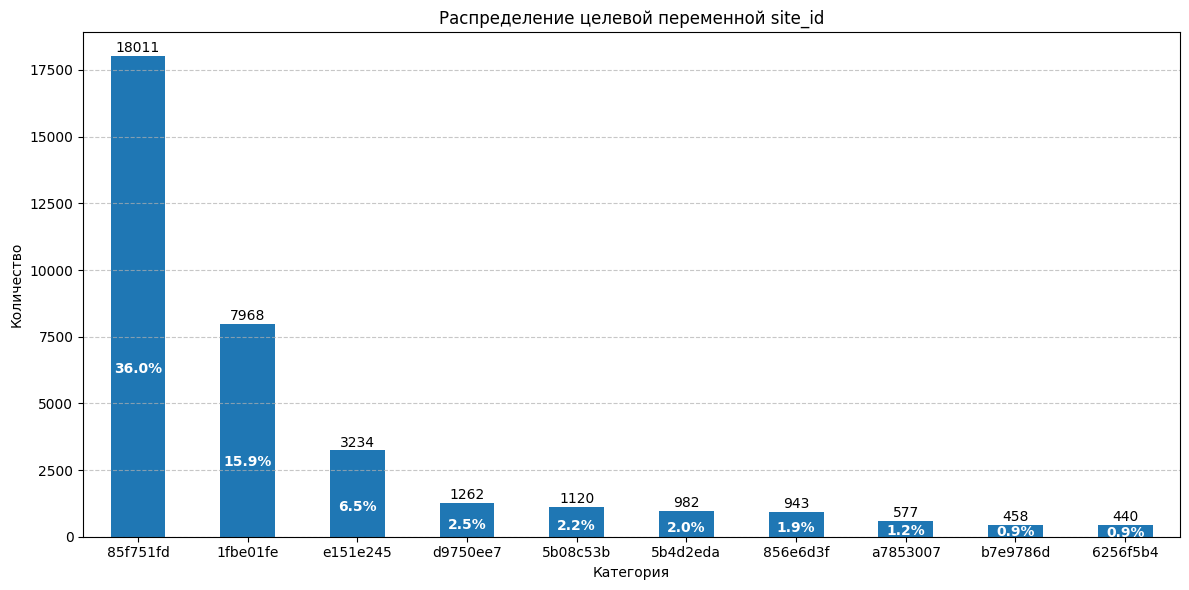

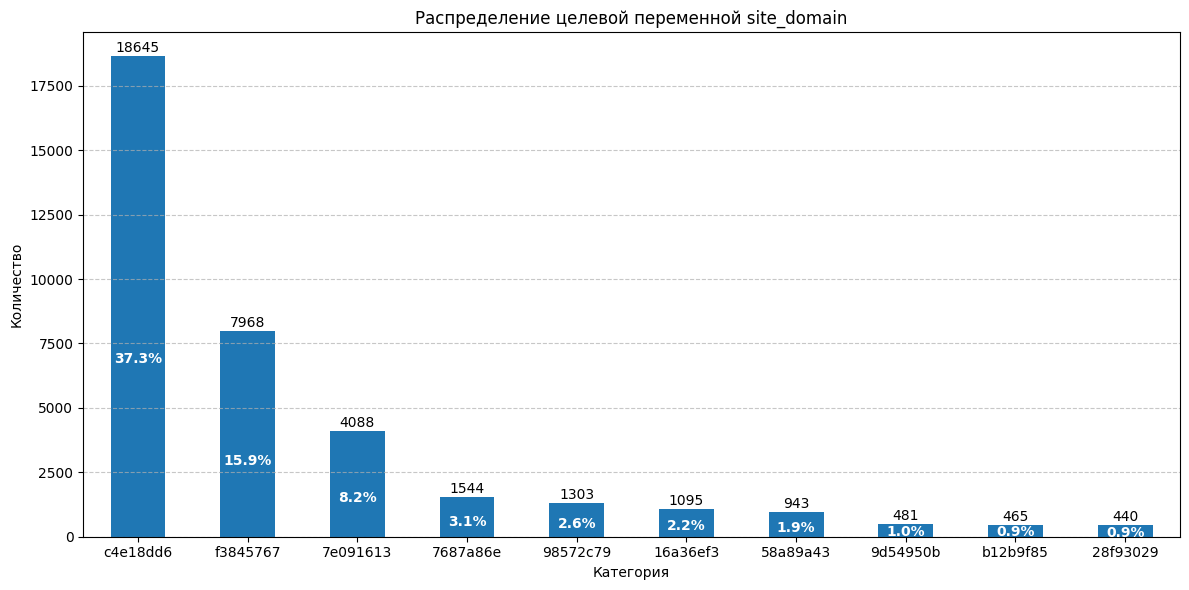

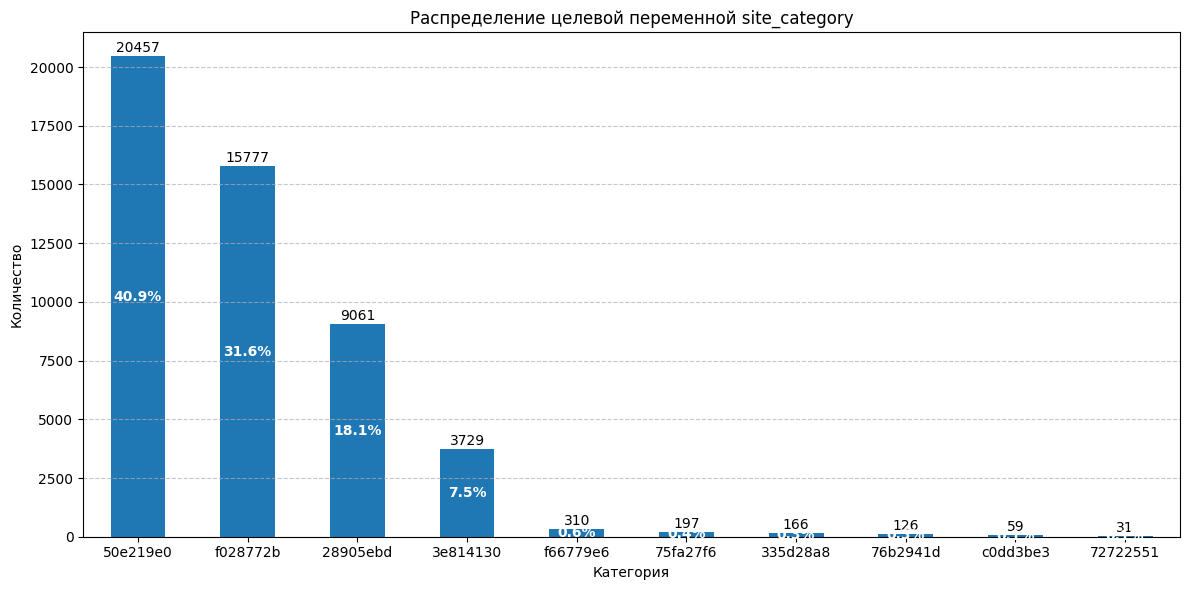

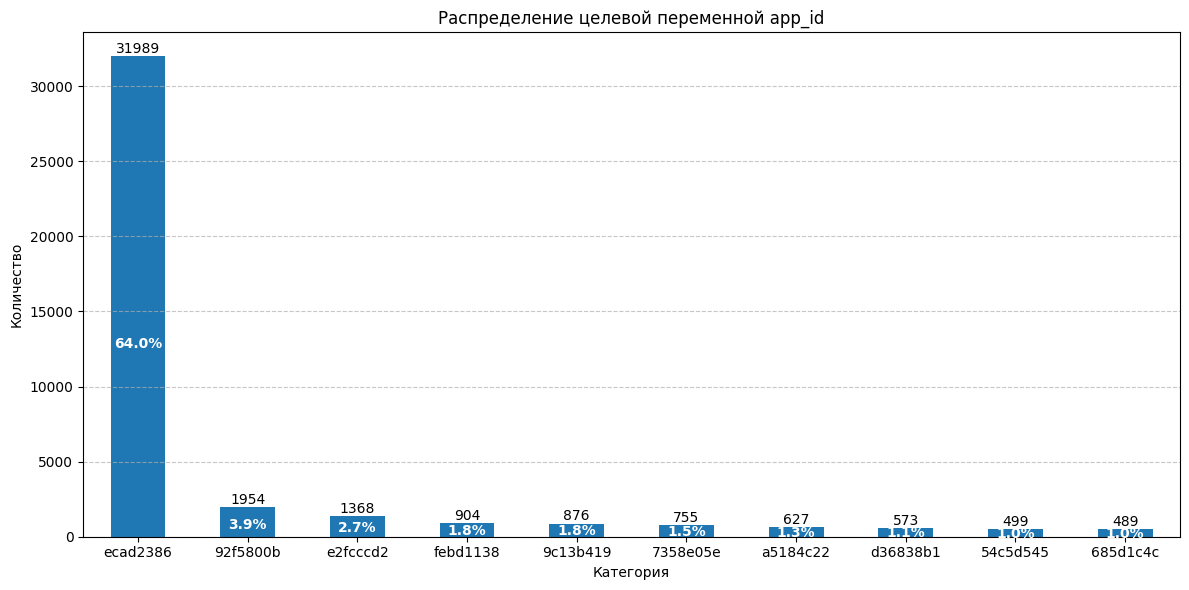

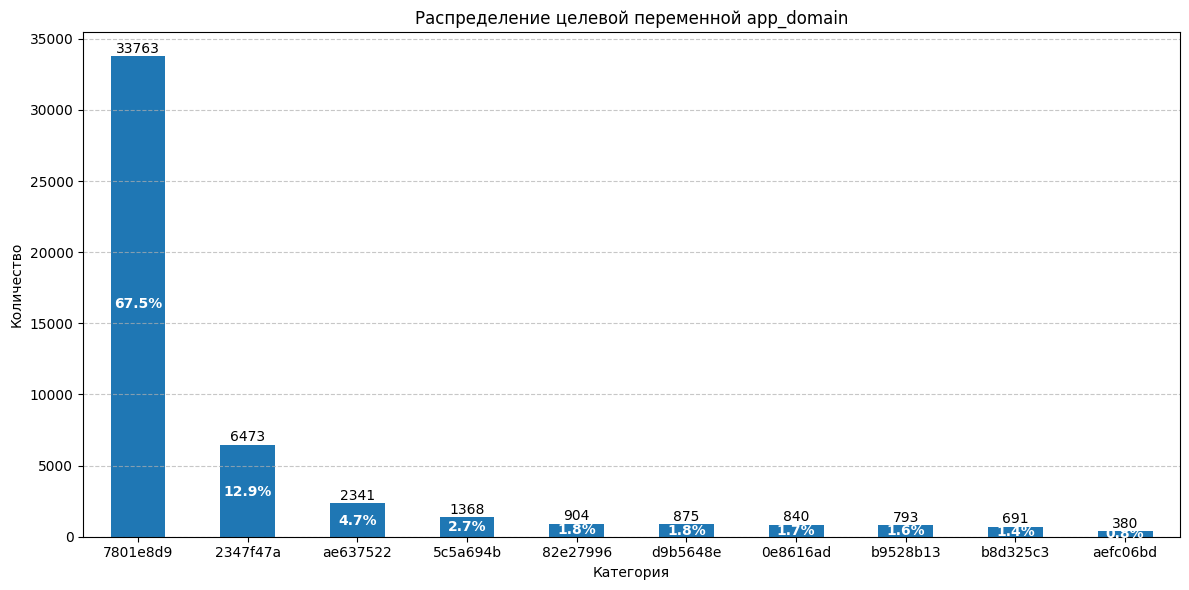

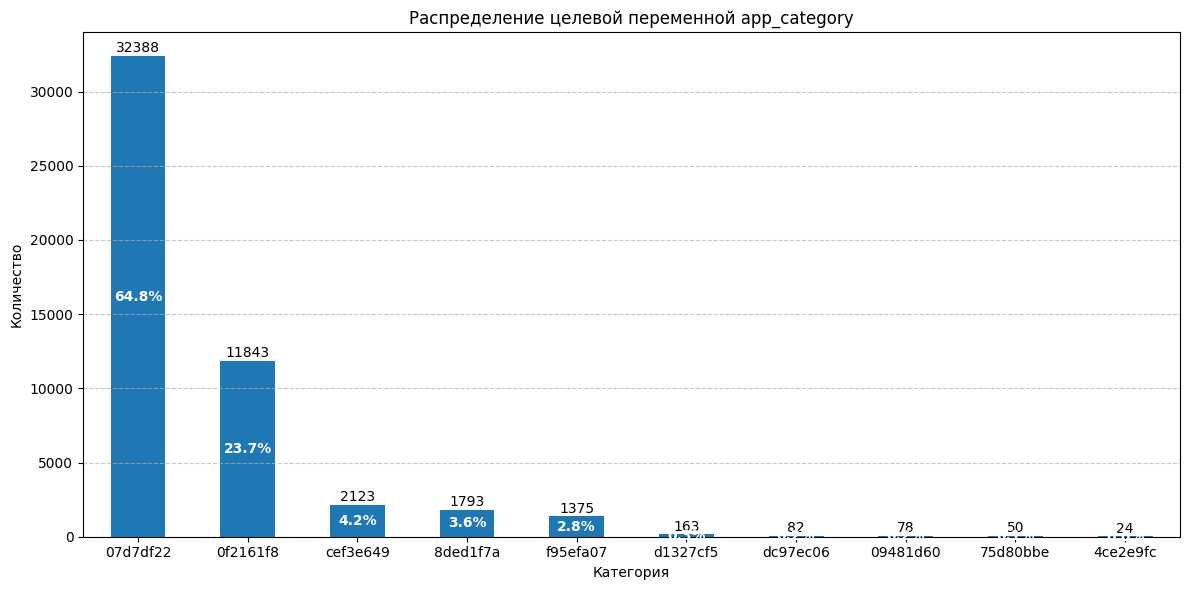

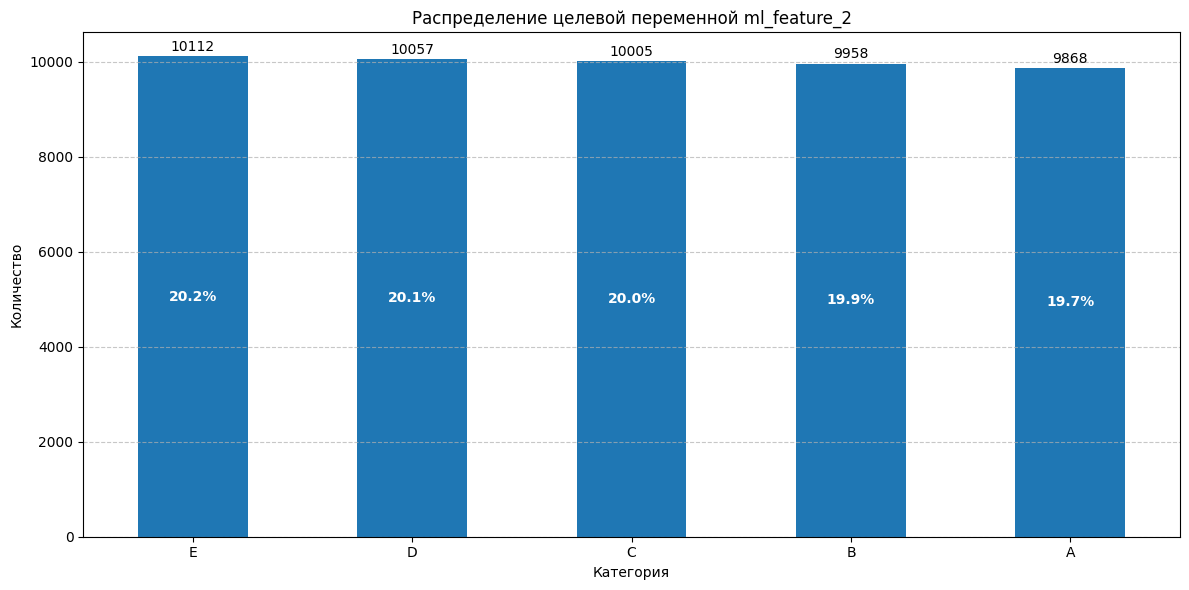

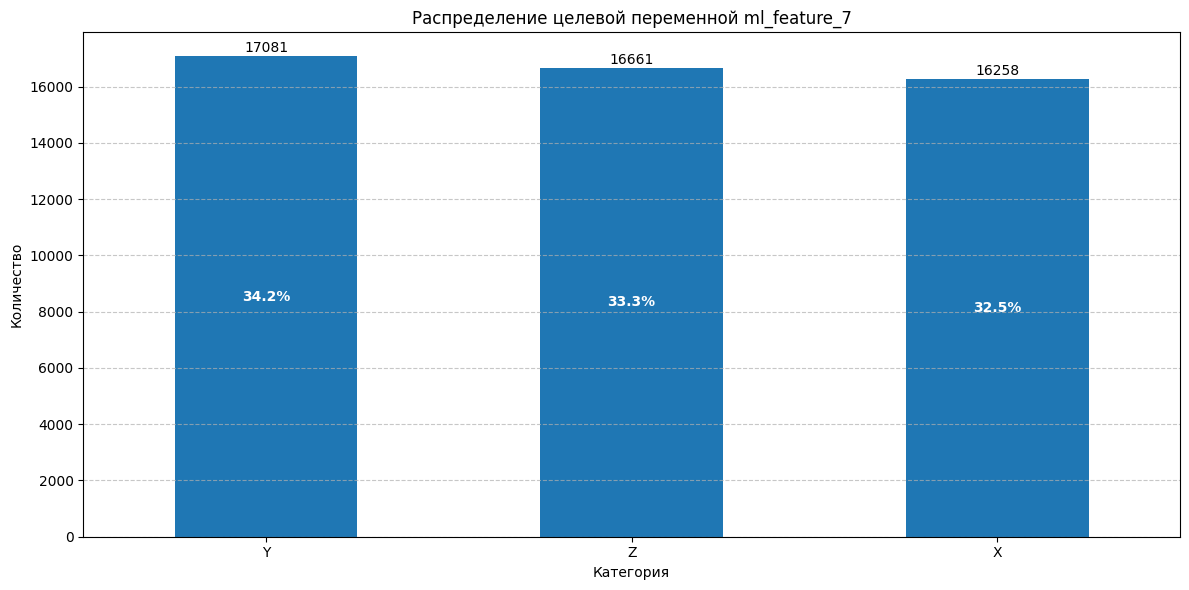

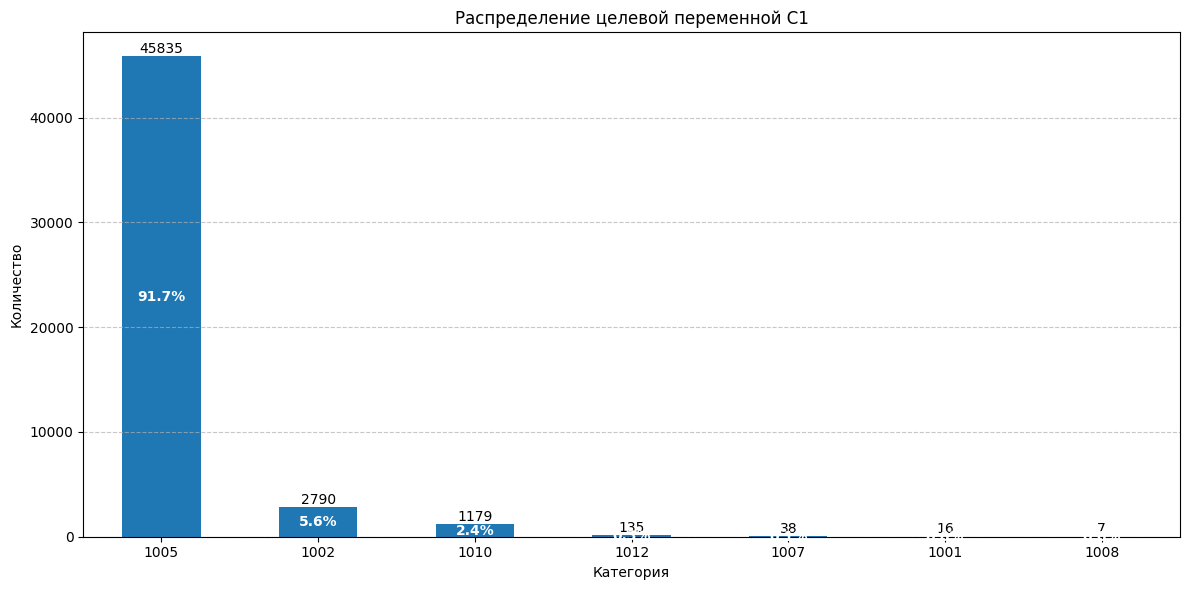

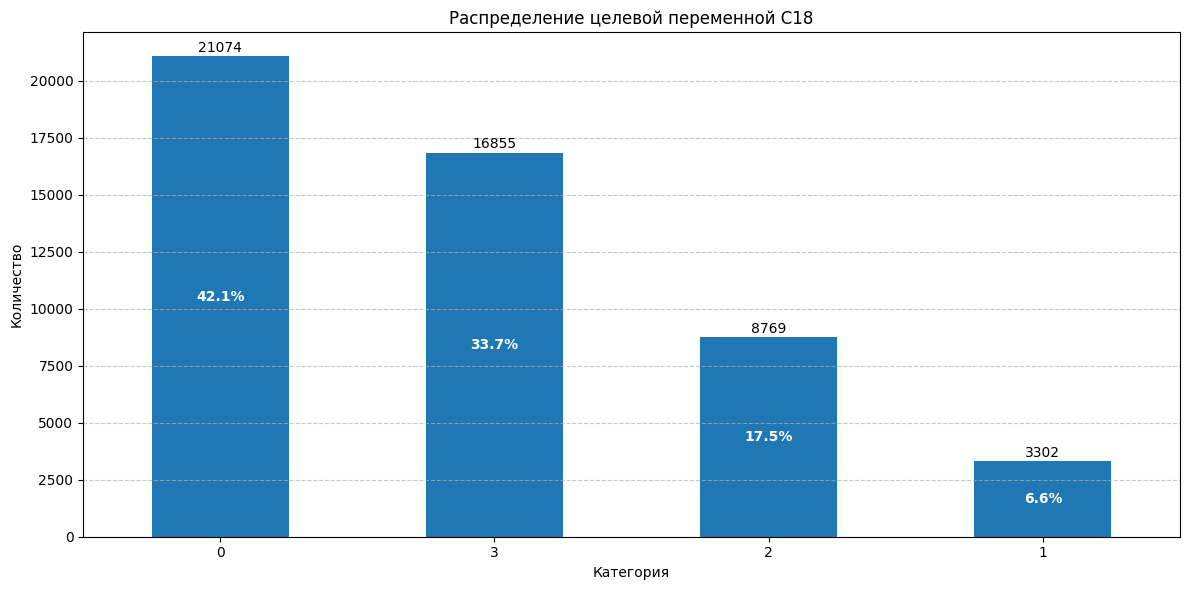

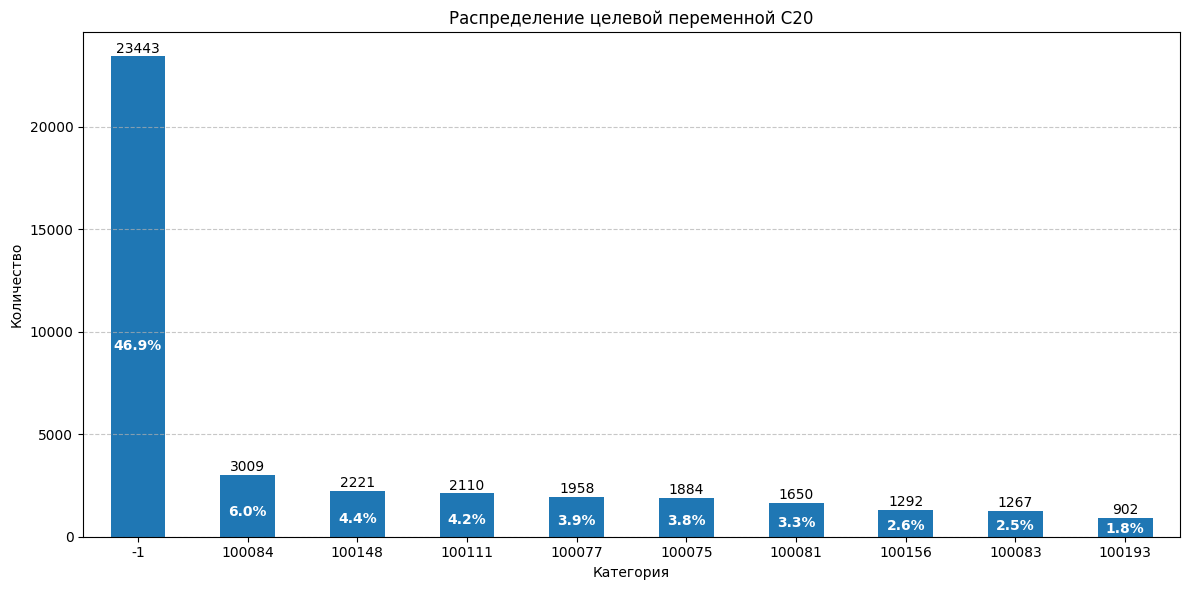

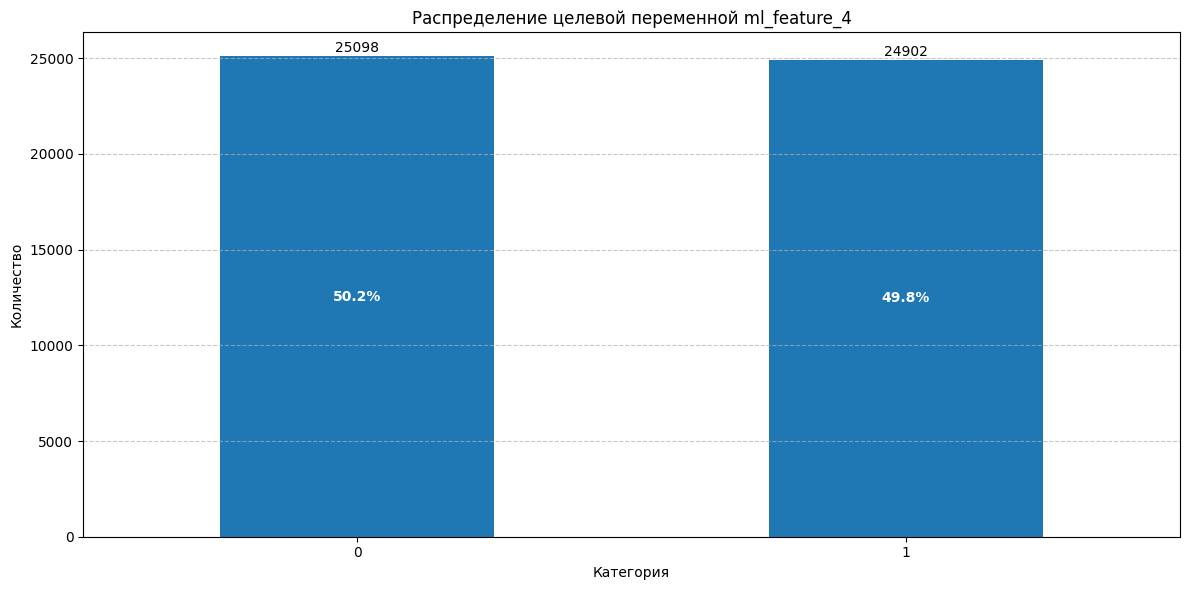

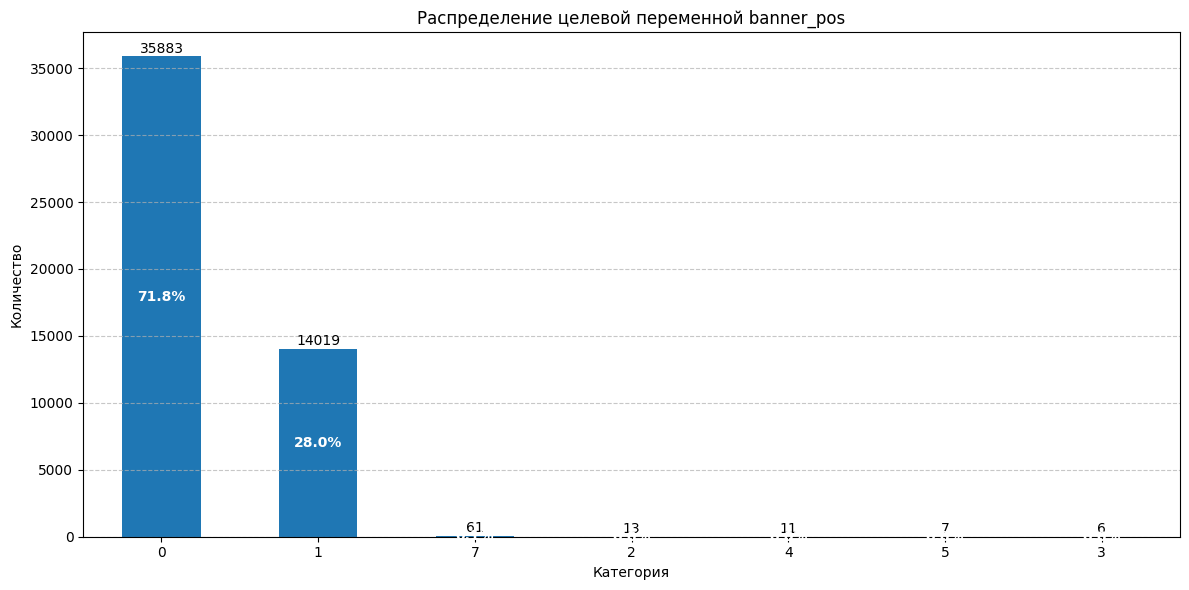

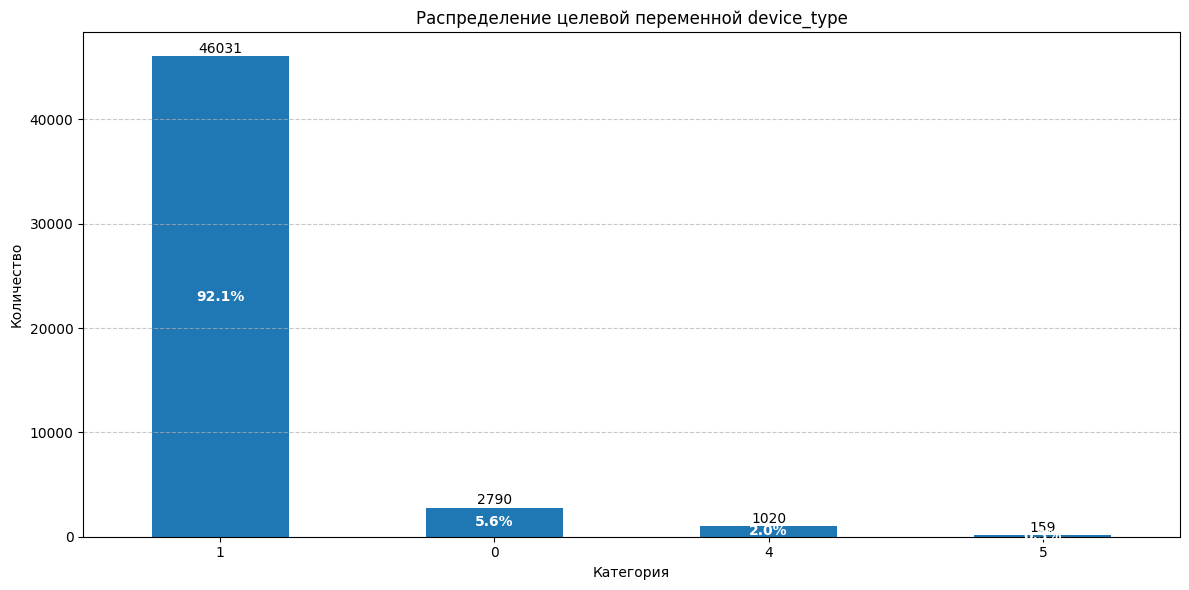

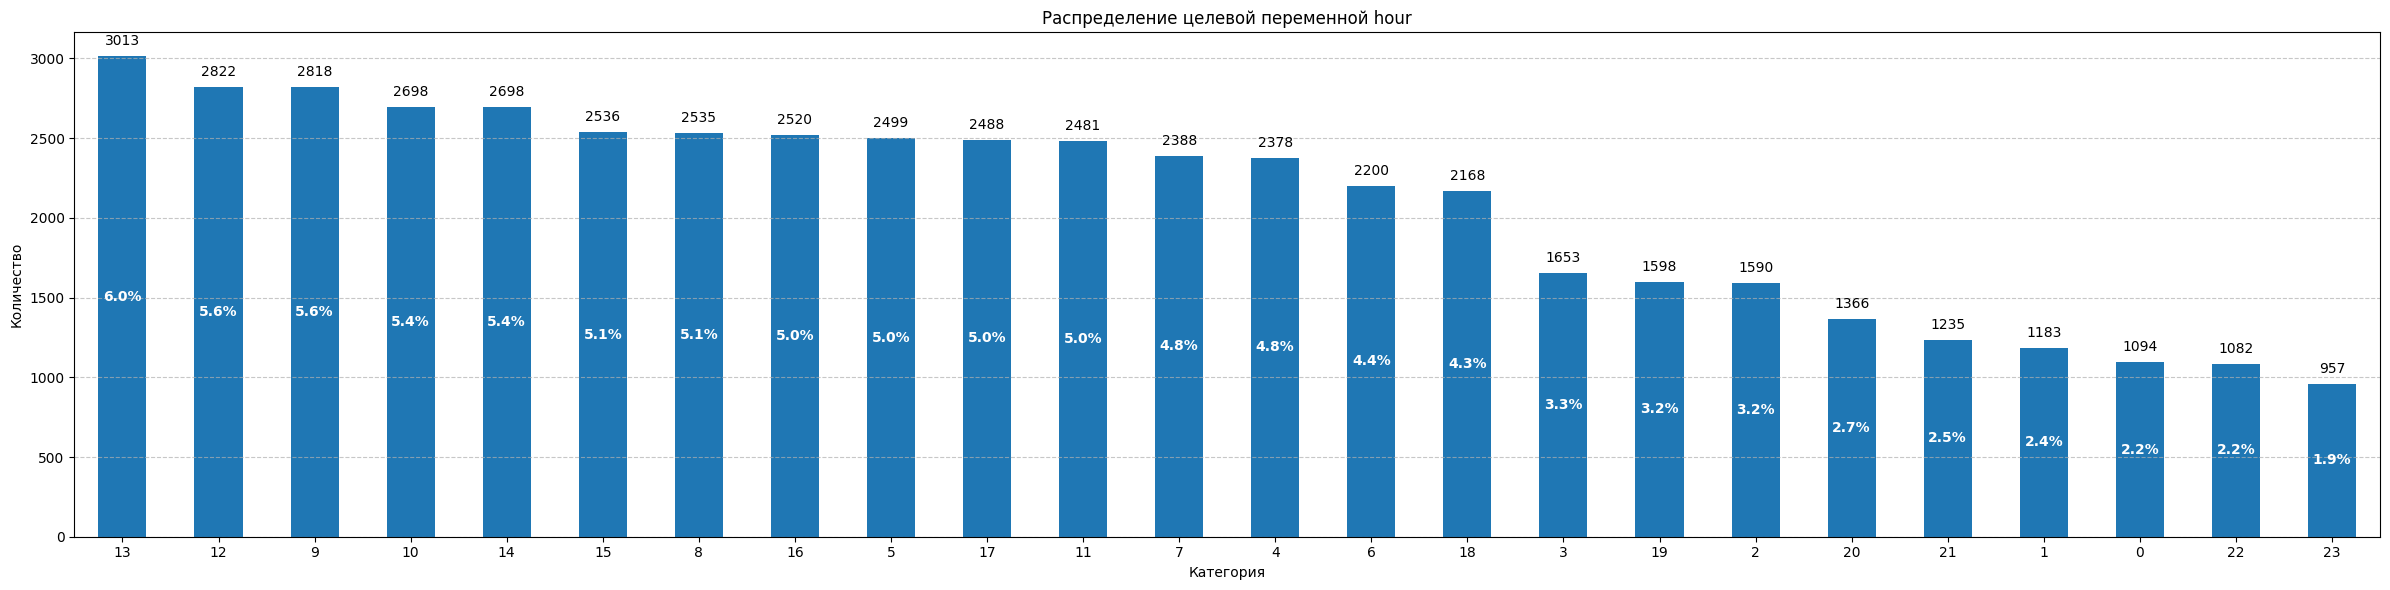

In [26]:
for feature in categorical_features:
    if feature == 'hour':
        top_n = 24
        fs = (24, 6)
    else:
        top_n = 10
        fs = (12, 6)
    plot_bar_chart(data=df_work[feature], figsize=fs, title=f'Распределение целевой переменной {feature}', top_n=top_n)

#### Анализ категориальных признаков

**1. Признаки, подходящие для One-Hot Encoding**

Эти признаки имеют умеренную кардинальность (до 10 уникальных значений), поэтому прямое бинарное кодирование безопасно и информативно:

- `ml_feature_2` (5);
- `ml_feature_7` (3);
- `C1` (7);
- `banner_pos` (4);
- `device_type` (4).

**2. Признаки с высокой кардинальностью (требуют специальных методов)**

Для этих признаков прямое One-Hot Encoding не рекомендуется из-за риска переобучения (создадут тысячи новых колонок):

- `site_id` (1160);
- `site_domain` (1013);
- `app_id` (976);
- `app_domain` (67);
- `hour` (24);
- `app_category` (22);
- `site_category` (18).

**3. Замена пропущенных значений в SimpleImputer**
Учитывая распределение значений в вкатегориальныъ переменных метод замены пропусков на моду будет использован в тех переменных, где есть явный дисбаланс в распределении (`site_id`, `site_domain`, `site_category`, `app_id`, `app_domain`, `app_category`, `C1`, `banner_pos`, `device_type`).
Признаки `ml_feature_2`, `ml_feature_7` имеют сбалансирвоанное распределение и замена пропусков будет осуществляться на заглушку 'unknown'.
Исключение составляет `hour`, где также наблюдается баланс распределения значений. Но здесь будет логично заполнить именно самым часто встречающимся значением 13. Вместе с ближайшим к нему значением **12** они в сумме собирают почти 12% показов баннеров. 

**Рекомендуемые методы обработки:**
- **Target Encoder**: замена категории на среднее значение целевой переменной (`click`) для этой категории.
- **LeaveOneOutEncoder**: замена категории на среднее значение целевой переменной с защитой от утечки данных.



#### Краткий итог

- **One-Hot Encoding:** `ml_feature_2`, `ml_feature_7`, `C1`, `banner_pos`, `device_type`.
- **Target Encoder / LeaveOneOutEncoder:** `app_domain`, `app_category`, `site_category`, `site_id`, `site_domain`, `app_id`, `hour`.
- **Замена пропусков (стратегия заполнения в SimpleImputer):**
  - **На моду (самое частое значение):** применяется к переменным с явным дисбалансом в распределении — `site_id`, `site_domain`, `site_category`, `app_id`, `app_domain`, `app_category`, `C1`, `banner_pos`, `device_type`.
  - **На заглушку `'unknown'`:** используется для сбалансированных признаков — `ml_feature_2`, `ml_feature_7`.
  - **Исключение (специальная логика для `hour`):** заполняется самым часто встречающимся значением **13**, так как вместе с ближайшим значением **12** они охватывают почти 12% показов баннеров.

___

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

In [27]:
df_work[numerical_features].describe()

,C14,C15,C16,C17,C19,C21,ml_feature_1,ml_feature_10,ml_feature_3,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,18826.648680,318.86640,59.692480,2109.781020,227.703800,83.685180,-0.002445,0.020226,-0.036381,0.034729,0.022948,0.025465,0.035361
std,4983.064178,20.56153,46.720842,612.963141,351.592108,70.539513,1.000280,0.303309,5.792335,1.002116,0.656690,0.578026,0.505034
min,375.000000,120.00000,20.000000,112.000000,33.000000,13.000000,-4.631262,-1.287965,-9.999742,-4.631853,-1.000000,-0.999965,-2.147526
25%,16920.000000,320.00000,50.000000,1823.000000,35.000000,23.000000,-0.677784,-0.182386,-5.059555,-0.639829,-0.579775,-0.470627,-0.304077
50%,20346.000000,320.00000,50.000000,2323.000000,39.000000,61.000000,-0.003776,0.018930,-0.056155,0.028112,0.037786,0.027348,0.035985
75%,21916.000000,320.00000,50.000000,2526.000000,171.000000,108.000000,0.673534,0.224080,4.985939,0.707594,0.637131,0.521117,0.374152
max,24043.000000,1024.00000,1024.000000,2757.000000,1839.000000,255.000000,3.793828,1.202300,9.999975,4.230623,1.000000,1.119858,2.120786


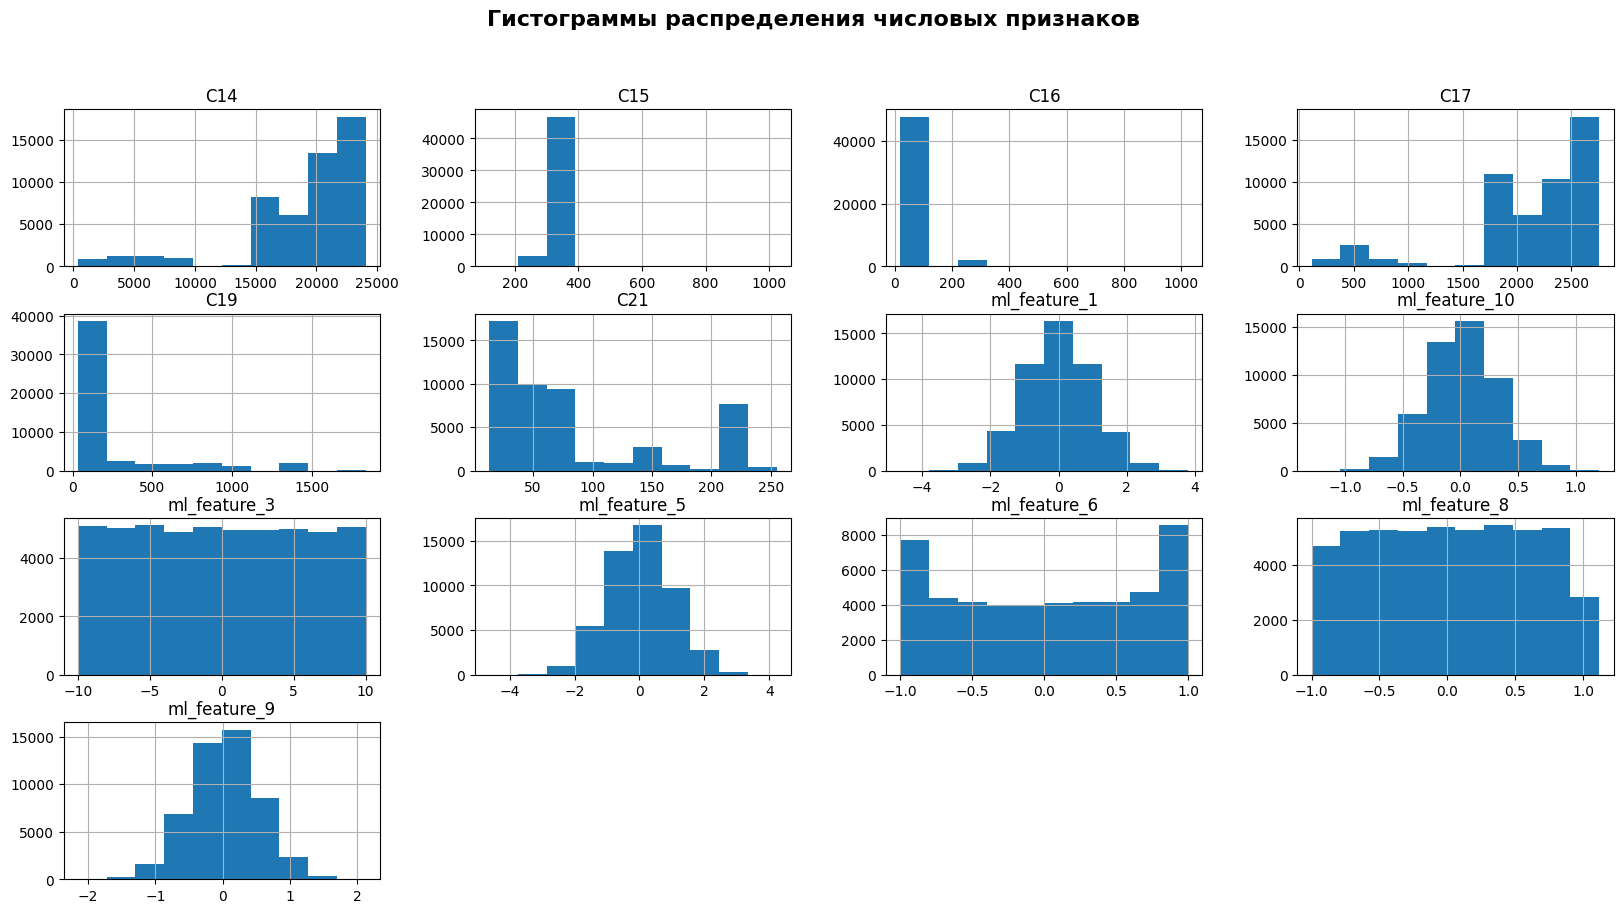

In [28]:
df_work[numerical_features].hist(figsize=(20, 10))
plt.suptitle('Гистограммы распределения числовых признаков', fontsize=16, fontweight='bold')
plt.show()

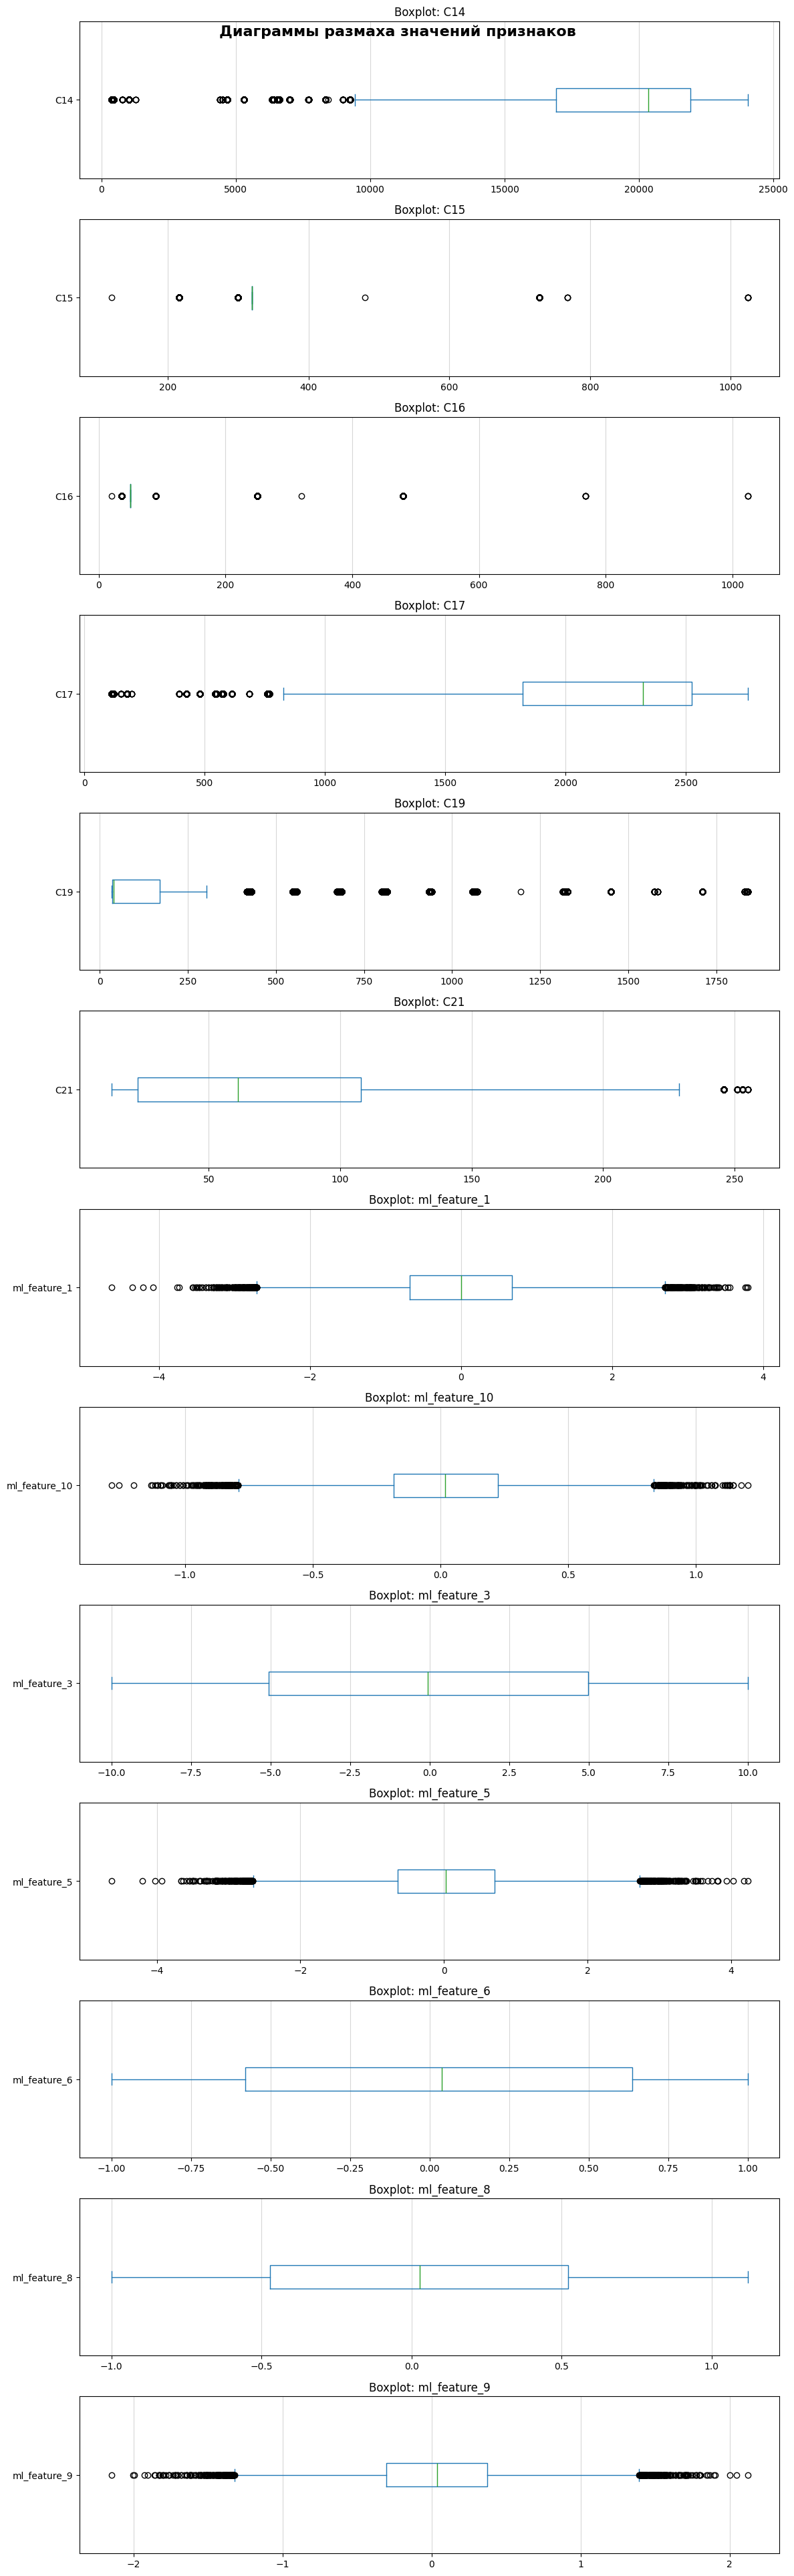

In [29]:
fig, axes = plt.subplots(nrows=len(numerical_features), ncols=1, figsize=(12, 3 * len(numerical_features)))

for i, feature in enumerate(numerical_features):
    df_work[feature].plot.box(ax=axes[i], vert=False)
    axes[i].set_title(f'Boxplot: {feature}')
    axes[i].tick_params(axis='x', labelrotation=0)
    axes[i].grid(axis='x', alpha=0.5) 

plt.suptitle('Диаграммы размаха значений признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
df_work[numerical_features].corr(method='pearson').style.background_gradient(cmap='coolwarm')

,C14,C15,C16,C17,C19,C21,ml_feature_1,ml_feature_10,ml_feature_3,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9
C14,1.000000,0.002022,0.036368,0.975887,-0.134061,0.412740,-0.003374,-0.010471,-0.010921,-0.011816,-0.007740,-0.009721,-0.004935
C15,0.002022,1.000000,-0.047837,0.000576,0.057696,-0.002735,-0.005830,-0.001476,0.002503,-0.005037,-0.003362,-0.004614,-0.004173
C16,0.036368,-0.047837,1.000000,0.046258,-0.067110,-0.087945,0.004533,0.021003,-0.001508,0.002968,0.014411,0.013058,0.018533
C17,0.975887,0.000576,0.046258,1.000000,-0.129542,0.426306,-0.002188,-0.010083,-0.010885,-0.012758,-0.006849,-0.008992,-0.003551
C19,-0.134061,0.057696,-0.067110,-0.129542,1.000000,-0.137029,0.004400,0.002755,0.002841,0.009399,0.000637,0.007883,0.000649
C21,0.412740,-0.002735,-0.087945,0.426306,-0.137029,1.000000,-0.003427,-0.006955,0.001821,-0.006612,0.003456,-0.004653,-0.003969
ml_feature_1,-0.003374,-0.005830,0.004533,-0.002188,0.004400,-0.003427,1.000000,0.004985,-0.001889,0.003125,0.003031,-0.000313,0.001853
ml_feature_10,-0.010471,-0.001476,0.021003,-0.010083,0.002755,-0.006955,0.004985,1.000000,-0.004643,0.007601,0.013620,0.010767,0.015627
ml_feature_3,-0.010921,0.002503,-0.001508,-0.010885,0.002841,0.001821,-0.001889,-0.004643,1.000000,0.000332,-0.003392,-0.006767,0.001556
ml_feature_5,-0.011816,-0.005037,0.002968,-0.012758,0.009399,-0.006612,0.003125,0.007601,0.000332,1.000000,0.005570,0.008728,0.008086


In [31]:
df_work[numerical_features].corr(method='spearman').style.background_gradient(cmap='coolwarm')

,C14,C15,C16,C17,C19,C21,ml_feature_1,ml_feature_10,ml_feature_3,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9
C14,1.000000,0.013371,-0.031778,0.976718,-0.023040,0.384854,-0.004127,-0.011263,-0.009296,-0.008957,-0.004253,-0.007793,-0.005306
C15,0.013371,1.000000,-0.550589,0.003161,0.082878,0.107070,-0.002232,-0.017830,0.001510,-0.006735,-0.008636,-0.012205,-0.013400
C16,-0.031778,-0.550589,1.000000,-0.018098,-0.045092,-0.133977,0.001772,0.019384,-0.003834,0.006884,0.016222,0.013087,0.015279
C17,0.976718,0.003161,-0.018098,1.000000,-0.038317,0.392314,-0.002918,-0.011160,-0.008341,-0.008748,-0.003346,-0.007288,-0.004277
C19,-0.023040,0.082878,-0.045092,-0.038317,1.000000,-0.254405,0.005855,0.001617,0.002192,-0.001327,0.000047,0.008203,0.001426
C21,0.384854,0.107070,-0.133977,0.392314,-0.254405,1.000000,-0.001868,-0.007958,0.001636,-0.007981,-0.001083,-0.006245,-0.006771
ml_feature_1,-0.004127,-0.002232,0.001772,-0.002918,0.005855,-0.001868,1.000000,0.004836,-0.001176,0.000767,0.003142,-0.000739,0.002037
ml_feature_10,-0.011263,-0.017830,0.019384,-0.011160,0.001617,-0.007958,0.004836,1.000000,-0.004875,0.006504,0.014438,0.010710,0.013193
ml_feature_3,-0.009296,0.001510,-0.003834,-0.008341,0.002192,0.001636,-0.001176,-0.004875,1.000000,0.002379,-0.003842,-0.006816,0.002910
ml_feature_5,-0.008957,-0.006735,0.006884,-0.008748,-0.001327,-0.007981,0.000767,0.006504,0.002379,1.000000,0.006058,0.006970,0.008049


In [32]:
df_work[numerical_features].corr(method='kendall').style.background_gradient(cmap='coolwarm')

,C14,C15,C16,C17,C19,C21,ml_feature_1,ml_feature_10,ml_feature_3,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9
C14,1.000000,0.010365,-0.025305,0.938689,-0.012515,0.294172,-0.002764,-0.007531,-0.006206,-0.006001,-0.002842,-0.005217,-0.003548
C15,0.010365,1.000000,-0.549747,0.001967,0.071739,0.090778,-0.001813,-0.014501,0.001229,-0.005477,-0.007023,-0.009925,-0.010896
C16,-0.025305,-0.549747,1.000000,-0.014197,-0.039009,-0.113453,0.001439,0.015750,-0.003115,0.005590,0.013178,0.010633,0.012409
C17,0.938689,0.001967,-0.014197,1.000000,-0.023533,0.305918,-0.001970,-0.007523,-0.005613,-0.005904,-0.002245,-0.004914,-0.002885
C19,-0.012515,0.071739,-0.039009,-0.023533,1.000000,-0.184567,0.004152,0.001154,0.001565,-0.000942,0.000041,0.005824,0.001001
C21,0.294172,0.090778,-0.113453,0.305918,-0.184567,1.000000,-0.001301,-0.005513,0.001142,-0.005557,-0.000754,-0.004368,-0.004695
ml_feature_1,-0.002764,-0.001813,0.001439,-0.001970,0.004152,-0.001301,1.000000,0.003226,-0.000778,0.000525,0.002098,-0.000494,0.001368
ml_feature_10,-0.007531,-0.014501,0.015750,-0.007523,0.001154,-0.005513,0.003226,1.000000,-0.003248,0.004323,0.009607,0.007142,0.008789
ml_feature_3,-0.006206,0.001229,-0.003115,-0.005613,0.001565,0.001142,-0.000778,-0.003248,1.000000,0.001595,-0.002534,-0.004543,0.001952
ml_feature_5,-0.006001,-0.005477,0.005590,-0.005904,-0.000942,-0.005557,0.000525,0.004323,0.001595,1.000000,0.004036,0.004646,0.005355


c:\Users\artem\ds12\ds12_projects\venv_ds12\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1013. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(
c:\Users\artem\ds12\ds12_projects\venv_ds12\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable site_id is large: 1160. Are you sure this is not an interval variable? Analysis for pairs of variables including site_id can be slow.
  warnings.warn(


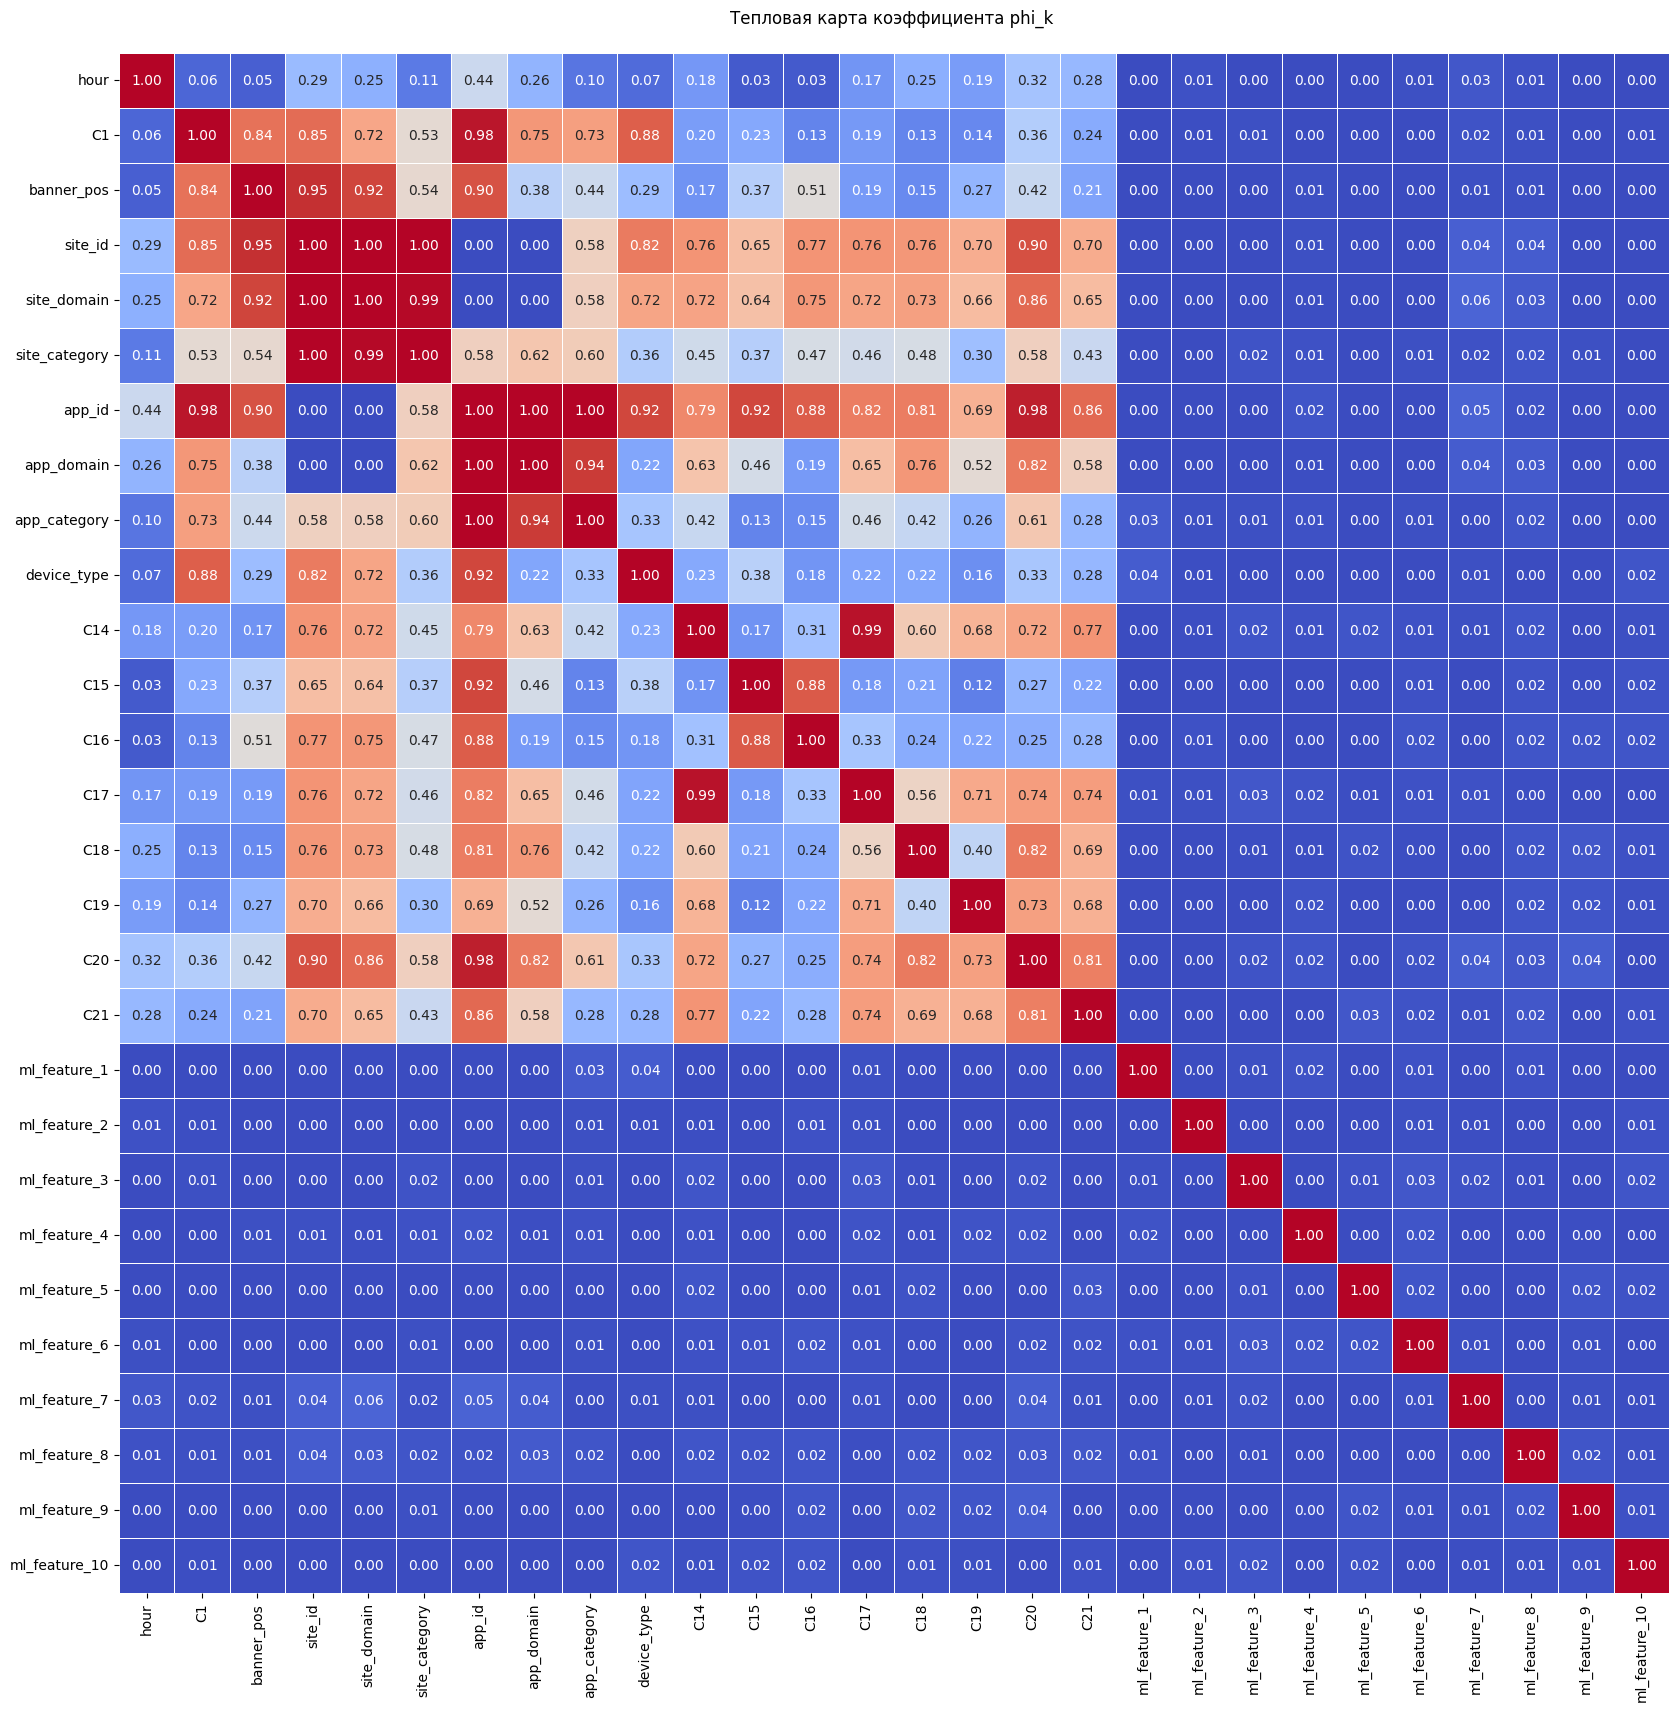

In [34]:
# Строим тепловую карту
plt.figure(figsize=(20, 20))

correlation_matrix = df_work.drop(columns='click').phik_matrix(interval_cols=numerical_features)

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
data_heatmap = correlation_matrix
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n')

# Выводим график
plt.show()

___

___

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.